# EAUI 2026 — Procesamiento de datos

Carga, recodifica y prepara la Encuesta de Acceso y Uso de Internet SUBTEL 2026.

**Orden de ejecución:** Carga → GSE → Etiquetas → NS/NR → Renombrado → Recodificaciones → Funciones

## 1. Carga del archivo

In [3]:
import pyreadstat, re, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

df, meta = pyreadstat.read_sav("/Users/tomas/github/eaui_subtel/data/sav/2026.sav")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 5,000 | Columnas: 587


## 2. GSE derivado

In [4]:
def _educ_cat(e):
    if pd.isna(e): return None
    e = int(e)
    return 'basica' if e <= 3 else 'media' if e <= 7 else 'tecnica' if e <= 9 else 'universitaria'

_ORDEN_GSE = ['AB','C1','C2','C3','D','E']
_GSE_MAP = {
    (1,'basica'):'E',  (1,'media'):'E',  (1,'tecnica'):'D',  (1,'universitaria'):'D',
    (2,'basica'):'E',  (2,'media'):'D',  (2,'tecnica'):'D',  (2,'universitaria'):'C3',
    (3,'basica'):'D',  (3,'media'):'C3', (3,'tecnica'):'C3', (3,'universitaria'):'C2',
    (4,'basica'):'C3', (4,'media'):'C2', (4,'tecnica'):'C2', (4,'universitaria'):'C1',
    (5,'basica'):'C2', (5,'media'):'C1', (5,'tecnica'):'C1', (5,'universitaria'):'AB',
    (6,'basica'):'C1', (6,'media'):'AB', (6,'tecnica'):'AB', (6,'universitaria'):'AB',
}

eg = df['A10'].apply(_educ_cat)
df['gse'] = pd.Categorical(df['A11'].combine(eg, lambda o, e: np.nan if pd.isna(o) or e is None else _GSE_MAP.get((int(o), e), np.nan)), categories=_ORDEN_GSE, ordered=True)
print('GSE:', df['gse'].value_counts().reindex(_ORDEN_GSE).to_dict())

GSE: {'AB': 342, 'C1': 533, 'C2': 988, 'C3': 1316, 'D': 833, 'E': 988}


## 3. Etiquetas limpias

In [5]:
def _clean_label(label):
    if not label: return label
    label = label.strip()
    if re.match(r'^[A-Z]\w+[\._ ]\w+\s*\.-?', label):
        if ':' in label: r = label.split(':')[-1].strip(); return r if r else label
        if '?' in label: r = label.split('?')[-1].strip().lstrip(':').strip(); return r if r else label
        return re.sub(r'^[A-Z]\w+[\._ ]\w+[\s\._ \-]+', '', label).strip().lstrip('.-').strip()
    if '[' in label: return re.sub(r'^\d+[\.\-]+\s*', '', label[:label.index('[')].strip()).strip()
    return re.sub(r'^\d+[\.\-]+\s*', '', label).strip()

etiquetas_limpias = {col: _clean_label(label) for col, label in zip(meta.column_names, meta.column_labels) if label}
print(f"Etiquetas procesadas: {len(etiquetas_limpias)}")

Etiquetas procesadas: 587


## 4. Diccionario de variables

In [6]:
diccionario = pd.DataFrame({'variable': meta.column_names, 'etiqueta': meta.column_labels})
diccionario.head(20)

,variable,etiqueta
0,REGISTRO,Número de registro
1,FECHAFIN,Fecha de fin de la entrevista
2,COD_REGION,Región
3,COMUNA_DEF,Comuna
4,ZONA,ZONA
5,A9,A9.- ¿Cuál es su parentesco con el Jefe /a de ...
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."
7,A11,A11.- Y ¿Cuál es la profesión o trabajo o acti...
8,A12_11,Aymara [A12.- ¿Algún miembro de este hogar per...
9,A12_2,Rapa-Nui [A12.- ¿Algún miembro de este hogar p...


In [7]:
busqueda = 'A10'
diccionario[diccionario['variable'].str.contains(busqueda, case=False) | diccionario['etiqueta'].str.contains(busqueda, case=False, na=False)]

,variable,etiqueta
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."


In [8]:
variable = 'Q13'
labels = meta.variable_value_labels.get(variable, {})
if labels:
    for k, v in labels.items(): print(f'  {k} -> {v}')
else:
    print(f"'{variable}' no tiene etiquetas de valor.")

  1.0 -> Banda Ancha Fija O Wifi [Adsl / Cable Modem / FibraÓptica / Wisp]
  2.0 -> Banda Ancha Móvil [Bam]
  3.0 -> Internet Móvil Con Plan O Bolsa De Gigas/Megas De Un Teléfono Móvil [Smartphone] / Tablet
  4.0 -> Conexión Satelital


## 5. Tratamiento NS/NR

In [9]:
for col in ['P11','Q7_4','P17_1','P17_2','P17_3','P17_4','P17_5','P19_1','P19_2','P19_3','P19_4','Q40_1','Q40_2','Q40_3','Q40_4','Q40_5','Q42','Q42_1']:
    if col in df.columns: df[col] = df[col].replace(9999999, np.nan)
print('NS/NR reemplazados por NaN.')

NS/NR reemplazados por NaN.


## 6. Renombrado y recodificación educación

In [10]:
MAP_EDUC = {1:'Sin educación formal', 2:'Básica incompleta', 3:'Básica completa', 4:'Media CH incompleta', 5:'Media TP incompleta', 6:'Media CH completa', 7:'Media TP completa', 8:'Superior técnica incompleta', 9:'Superior técnica completa', 10:'Superior universitaria incompleta', 11:'Superior universitaria completa'}
MAP_OCUP = {1:'Trabajos ocasionales e informales', 2:'Oficio menor - obrero no calificado', 3:'Obrero calificado - microempresario', 4:'Empleado medio - técnico - prof. independiente', 5:'Ejecutivo medio - prof. universitario', 6:'Alto ejecutivo - empresario - directivo'}

rename_map = {'REGISTRO':'id', 'FECHAFIN':'fecha_fin', 'COD_REGION':'region', 'COMUNA_DEF':'comuna', 'ZONA':'zona', 'A9':'parentesco_jh', 'A10':'educ_jh', 'A11':'ocupacion_jh', 'A12_1':'ingreso_hogar', 'Q1':'parentesco', 'Q1_1':'edad', 'Q1_2':'sexo', 'Q1_3':'educ', 'Q1_4':'ocupacion_encuestado', 'Q2':'actividad', 'P1':'acceso_internet_hogar', 'P2':'n_smartphones_hogar', 'P2_1':'n_computadores_hogar', 'P10':'tipo_acceso_fijo', 'P11':'pago_mensual_internet', 'P11_3':'velocidad_contratada', 'P11_4':'calidad_acceso', 'P11_5':'cuota_mensual_gb', 'P12_2':'tipo_plan', 'P12_1':'plan_movil_tipo', 'P14':'razon_no_acceso_principal', 'P15':'disposicion_contratar_fijo', 'Q5':'uso_computador', 'Q7':'uso_smartphone', 'Q7_1':'smartphone_propio', 'Q7_3':'plan_movil_tipo_ind', 'Q7_4':'pago_mensual_movil', 'Q9':'ultimo_uso_internet', 'Q10':'frecuencia_internet', 'Q11':'tiempo_diario_internet', 'Q13':'tipo_acceso_mas_usado', 'Q14':'uso_internet_hogar', 'Q15':'frecuencia_internet_hogar', 'Q16':'tiempo_diario_hogar', 'Q17':'uso_internet_fuera_hogar', 'Q18':'frecuencia_fuera_hogar', 'Q19':'tiempo_diario_fuera_hogar', 'Q23':'internet_facilita_trabajo', 'Q25':'internet_mejora_vida', 'Q27':'ultima_compra_online', 'Q31':'percepcion_proteccion', 'Q30_1':'reg_control_legal', 'Q30_2':'reg_control_familia', 'Q30_3':'reg_autocontrol', 'FE_HOGAR':'fe_hogar', 'FE_PERSONAS':'fe_personas', 'POND_HOGAR':'pond_hogar', 'POND_PERSONAS':'pond_personas'}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df['educ_jh'] = df['educ_jh'].map(MAP_EDUC)
df['ocupacion_jh'] = df['ocupacion_jh'].map(MAP_OCUP)
df['ocupacion_encuestado'] = df['ocupacion_encuestado'].map({**MAP_OCUP, 7:'Sin trabajo remunerado'})
print(f"Renombradas: {len(rename_map)} | Columnas: {df.shape[1]}")

Renombradas: 53 | Columnas: 588


## 7. Recodificaciones

In [11]:
df = df.copy()
REGIONES = {1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso', 6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos', 11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos', 15:'Arica y Parinacota', 16:'Ñuble'}
df['region'] = df['region'].map(REGIONES)
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'})
df['sexo'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})
df['educ'] = df['educ'].map(MAP_EDUC)
df['educ_grupo'] = df['educ'].map({'Sin educación formal':'Básica o menos', 'Básica incompleta':'Básica o menos', 'Básica completa':'Básica o menos', 'Media CH incompleta':'Media', 'Media TP incompleta':'Media', 'Media CH completa':'Media', 'Media TP completa':'Media', 'Superior técnica incompleta':'Superior', 'Superior técnica completa':'Superior', 'Superior universitaria incompleta':'Superior', 'Superior universitaria completa':'Superior'})
df['tramo_edad'] = pd.cut(df['edad'], bins=[0,17,29,44,59,200], labels=['Menor de 18','18-29','30-44','45-59','60 y más'], right=True)
df['actividad'] = df['actividad'].map({1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente', 4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante', 7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'})
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
df['tipo_acceso_fijo'] = df['tipo_acceso_fijo'].map({1:'ADSL', 2:'Cable/Módem', 3:'Fibra óptica', 4:'Inalámbrica', 5:'Satelital', 31:'WiFi', 32:'Antena', 33:'Banda ancha', 34:'Acceso telefónico', 88:'No sabe'})
df['velocidad_contratada'] = df['velocidad_contratada'].map({1:'Hasta 10 Mbps', 2:'Más de 10 a 100 Mbps', 3:'Más de 100 a 500 Mbps', 4:'Más de 500 Mbps a 1 Gbps', 5:'Más de 1 Gbps', 99:'NS/NR'})
df['tipo_plan'] = df['tipo_plan'].map({1:'Banda ancha desnuda', 2:'BA + TV Cable', 3:'BA + Telefonía fija', 4:'Triple pack (BA+TV+Tel)', 5:'Otros planes'})
df['tipo_acceso_mas_usado'] = df['tipo_acceso_mas_usado'].map({1.0:'Banda Ancha Fija / WiFi', 2.0:'Banda Ancha Móvil', 3.0:'Internet Móvil (Smartphone/Tablet)', 4.0:'Conexión Satelital'})
df['uso_computador'] = df['uso_computador'].map({1:'Sí', 2:'No'})
df['uso_smartphone'] = df['uso_smartphone'].map({1:'Sí', 2:'No'})
df['ultimo_uso_internet'] = df['ultimo_uso_internet'].map({1:'Hoy', 2:'Entre 2 y 3 días', 3:'Entre 3 y 7 días', 4:'Entre 1 y 4 semanas', 5:'Más de 4 semanas', 6:'Más de 12 meses', 7:'Nunca'})
df['frecuencia_internet'] = df['frecuencia_internet'].map({1:'Todos los días', 2:'Varias veces por semana', 3:'Al menos una vez al mes', 4:'Menos de una vez al mes'})
df['tiempo_diario_internet'] = df['tiempo_diario_internet'].map({1:'Menos de 1 hora', 2:'Entre 1 y 2 horas', 3:'Entre 2 y 4 horas', 4:'Más de 4 horas'})
df['percepcion_proteccion'] = df['percepcion_proteccion'].map({1:'Muy protegido', 2:'Protegido', 3:'Desprotegido', 4:'Muy desprotegido', 99:'NS/NR'})
df['internet_mejora_vida'] = df['internet_mejora_vida'].map({1:'Sí', 2:'No'})
df['internet_facilita_trabajo'] = df['internet_facilita_trabajo'].map({1:'Sí', 2:'No'})
print('Recodificaciones completadas.')
print(f"sexo: {df['sexo'].value_counts().to_dict()}")
print(f"acceso: {df['acceso_internet_hogar'].value_counts().to_dict()}")

Recodificaciones completadas.
sexo: {'Mujer': 2815, 'Hombre': 2185}
acceso: {'Sí': 4841, 'No': 159}


## 8. Ingreso del hogar

In [12]:
RANGOS_INGRESO = {11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None)}
MAP_PM = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in RANGOS_INGRESO.items()}
df['ingreso_pm'] = df['ingreso_hogar'].map(MAP_PM)
df['ingreso_tramo'] = pd.cut(df['ingreso_pm'], bins=[0, 384000, 540000, 798000, 1100000, 1700000, float('inf')], labels=['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil','$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'], right=True)
df['ingreso_grupo'] = df['ingreso_tramo'].map({'Hasta $384 mil':'Bajo', '$384 mil a $540 mil':'Bajo', '$540 mil a $798 mil':'Medio', '$798 mil a $1,1 millón':'Medio', '$1,1 millón a $1,7 millones':'Alto', 'Más de $1,7 millones':'Alto'})
print(df.groupby('gse', observed=True)['ingreso_pm'].agg(N='count', Promedio='mean').reindex(_ORDEN_GSE).round(0).astype({'N':int,'Promedio':int}))

        N  Promedio
gse                
AB    286   2097505
C1    444   1389884
C2    826    986176
C3   1112    799533
D     704    650022
E     846    539833


## 9. Funciones de análisis

In [13]:
ORDEN_CATEGORIAS = {'sexo':['Hombre','Mujer'], 'zona':['Urbana','Rural'], 'region':list(REGIONES.values()), 'educ':list(MAP_EDUC.values()), 'educ_grupo':['Básica o menos','Media','Superior'], 'tramo_edad':['Menor de 18','18-29','30-44','45-59','60 y más'], 'actividad':list({1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente', 4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante', 7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'}.values()), 'ocupacion_jh':list(MAP_OCUP.values()), 'ocupacion_encuestado':list({**MAP_OCUP, 7:'Sin trabajo remunerado'}.values()), 'gse':_ORDEN_GSE, 'ingreso_tramo':['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil','$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'], 'ingreso_grupo':['Bajo','Medio','Alto'], 'acceso_internet_hogar':['Sí','No'], 'uso_computador':['Sí','No'], 'uso_smartphone':['Sí','No'], 'internet_mejora_vida':['Sí','No'], 'internet_facilita_trabajo':['Sí','No'], 'tipo_acceso_fijo':['Fibra óptica','Cable/Módem','ADSL','Inalámbrica','Satelital','WiFi','Antena','Banda ancha','Acceso telefónico','No sabe'], 'tipo_acceso_mas_usado':['Banda Ancha Fija / WiFi','Banda Ancha Móvil','Internet Móvil (Smartphone/Tablet)','Conexión Satelital'], 'tipo_plan':['Banda ancha desnuda','BA + TV Cable','BA + Telefonía fija','Triple pack (BA+TV+Tel)','Otros planes'], 'ultimo_uso_internet':['Hoy','Entre 2 y 3 días','Entre 3 y 7 días','Entre 1 y 4 semanas','Más de 4 semanas','Más de 12 meses','Nunca'], 'frecuencia_internet':['Todos los días','Varias veces por semana','Al menos una vez al mes','Menos de una vez al mes'], 'tiempo_diario_internet':['Menos de 1 hora','Entre 1 y 2 horas','Entre 2 y 4 horas','Más de 4 horas'], 'percepcion_proteccion':['Muy protegido','Protegido','Desprotegido','Muy desprotegido','NS/NR'], 'velocidad_contratada':['Hasta 10 Mbps','Más de 10 a 100 Mbps','Más de 100 a 500 Mbps','Más de 500 Mbps a 1 Gbps','Más de 1 Gbps','NS/NR']}

def fordf(df_tabla, titulo=None):
    num_cols = df_tabla.select_dtypes(include=['number']).columns
    estilo = df_tabla.style.format({col: '{:,.0f}' if any(x in str(col).lower() for x in ['ponderado','total','n ']) else '{:.1f}' for col in num_cols})
    return estilo.set_caption(titulo) if titulo else estilo

def _ordenar(df_res, var, cruzada=False):
    if var not in ORDEN_CATEGORIAS: return df_res
    orden = ORDEN_CATEGORIAS[var]
    if cruzada:
        ok = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != 'Total']
        return df_res.reindex(ok + rst + (['Total'] if 'Total' in df_res.index else []))
    ok = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != 'Total']
    df_res[var] = pd.Categorical(df_res[var], categories=ok+rst+['Total'], ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)

def dstats(data_df, variables, tipo='frecuencia', cruce=None, factor=None, estilo=True):
    if isinstance(variables, str): variables = [variables]
    cols_check = variables + ([factor] if factor else []) + ([cruce] if cruce else [])
    for col in cols_check:
        if col not in data_df.columns: raise ValueError(f"Columna '{col}' no existe.")
    
    if tipo == 'frecuencia':
        var = variables[0]; tot = data_df[factor].sum()
        res = data_df.groupby(var, observed=True)[factor].sum().reset_index().rename(columns={factor:'n_ponderado'})
        res['porcentaje'] = (res['n_ponderado'] / tot * 100).round(2)
        res = pd.concat([res, pd.DataFrame({var:['Total'],'n_ponderado':[res['n_ponderado'].sum()],'porcentaje':[res['porcentaje'].sum().round(2)]})], ignore_index=True)
        res = _ordenar(res, var).set_index(var)
        return fordf(res, f"Frecuencia: '{var}' — base: {tot:,.0f} ({factor})") if estilo else res
    
    if tipo == 'cruzada':
        var, tot = variables[0], data_df[factor].sum()
        t = data_df.pivot_table(values=factor, index=var, columns=cruce, aggfunc='sum', fill_value=0, observed=False)
        tp = t.div(t.sum(axis=0), axis=1).mul(100).round(2)
        if var in ORDEN_CATEGORIAS: of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index]; t, tp = t.reindex(of), tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS: oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in t.columns]; t, tp = t[oc], tp[oc]
        t.loc['Total'], tp.loc['Total'] = t.sum(numeric_only=True), tp.sum(numeric_only=True).round(2)
        res = pd.concat([t[c].rename(f'n {c}') if c in t.columns else pd.Series() for c in t.columns] + [tp[c].rename(f'% {c}') if c in tp.columns else pd.Series() for c in tp.columns], axis=1)
        return fordf(res, f"Cruce: '{var}' según '{cruce}' — base: {tot:,.0f} ({factor})") if estilo else res
    
    raise ValueError(f"tipo '{tipo}' no soportado")

print('Funciones listas.')

Funciones listas.


## 10. Grupos de respuesta múltiple

In [14]:
def _cols_rm(prefix, exclude_prefix=None, exclude_suffix=None):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if exclude_prefix: cols = [c for c in cols if not c.startswith(exclude_prefix)]
    if exclude_suffix: cols = [c for c in cols if not c.endswith(exclude_suffix)]
    return cols

GRUPOS_RM = {
    'A12': ('Pueblos indígenas o tribales', _cols_rm('A12_', 'A12_1')),
    'A13': ('Condiciones permanentes salud', _cols_rm('A13_')),
    'A14': ('Situaciones laborales', _cols_rm('A14_', exclude_suffix='_OTRA')),
    'P3': ('Dispositivos acceso internet', _cols_rm('P3_', exclude_suffix='_OTRA')),
    'P4': ('Formas acceso pagado', _cols_rm('P4_')),
    'P6': ('Razones internet fijo', [c for c in _cols_rm('P6_', 'P6_1_', '_OTRA') if not c.startswith('P6_1_')]),
    'P6_1': ('Razones internet móvil', _cols_rm('P6_1_')),
    'P7': ('Protección menores', _cols_rm('P7_')),
    'P9': ('Dispositivos menores', _cols_rm('P9_')),
    'P12': ('Móvil 4G/5G', [c for c in df.columns if c in ['P12_11','P12_21','P12_31','P12_41']]),
    'P13': ('Razones no acceso fijo', _cols_rm('P13_', exclude_suffix='_OTRA')),
    'P16': ('Equipos interés sin internet', _cols_rm('P16_')),
    'Q6': ('Cómo aprendió usar PC', [c for c in _cols_rm('Q6_') if c not in ['Q6_1','Q6_OTRA']]),
    'Q7_2': ('Smartphone 4G/5G', [c for c in df.columns if c in ['Q7_2_1','Q7_2_2','Q7_2_3','Q7_2_4']]),
    'Q8': ('Habilidades digitales', _cols_rm('Q8_')),
    'Q11_1': ('Lugares uso ayer', _cols_rm('Q11_1_')),
    'Q12': ('Tipos acceso últimos 3m', _cols_rm('Q12_')),
    'Q20': ('Lugares fuera hogar', _cols_rm('Q20_')),
    'Q21': ('Actividades internet', [c for c in _cols_rm('Q21_') if c not in ['Q21_1','Q21_10','Q21_19','Q21_26','Q21_33','Q21_38','Q21_44']]),
    'Q28': ('Bienes servicios comprados', _cols_rm('Q28_', exclude_suffix='_OTRA')),
    'Q32': ('Actividades seguridad', _cols_rm('Q32_', exclude_suffix='_OTRA')),
    'Q33': ('Problemas seguridad', _cols_rm('Q33_', exclude_suffix='_OTRA')),
    'Q34': ('Razones no uso', _cols_rm('Q34_', exclude_suffix='_OTRA')),
    'Q37': ('Actividades terceros', _cols_rm('Q37_')),
    'Q39': ('Equipos interés no usuarios', _cols_rm('Q39_')),
}

def analizar_rm(grupo, factor='fe_hogar', top_n=None, estilo=True):
    if grupo not in GRUPOS_RM: raise ValueError(f"Grupo '{grupo}' no existe.")
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    base = df.loc[df[cols].notna().any(axis=1), factor].sum()
    filas = [{'variable': c, 'etiqueta': etiquetas_limpias.get(c, c), 'n_ponderado': int(df.loc[df[c]==1, factor].sum()), 'porcentaje': round(df.loc[df[c]==1, factor].sum() / base * 100, 1)} for c in cols]
    res = pd.DataFrame(filas).sort_values('porcentaje', ascending=False).reset_index(drop=True)
    if top_n: res = res.head(top_n)
    res.index += 1
    return fordf(res, f"{desc} — base: {int(base):,} ({factor})") if estilo else res

print("Grupos de respuesta múltiple:")
for k, (desc, cols) in GRUPOS_RM.items():
    print(f"  '{k}': {desc} ({len(cols)} opciones)")

Grupos de respuesta múltiple:
  'A12': Pueblos indígenas o tribales (8 opciones)
  'A13': Condiciones permanentes salud (7 opciones)
  'A14': Situaciones laborales (8 opciones)
  'P3': Dispositivos acceso internet (8 opciones)
  'P4': Formas acceso pagado (5 opciones)
  'P6': Razones internet fijo (13 opciones)
  'P6_1': Razones internet móvil (13 opciones)
  'P7': Protección menores (12 opciones)
  'P9': Dispositivos menores (4 opciones)
  'P12': Móvil 4G/5G (4 opciones)
  'P13': Razones no acceso fijo (29 opciones)
  'P16': Equipos interés sin internet (5 opciones)
  'Q6': Cómo aprendió usar PC (12 opciones)
  'Q7_2': Smartphone 4G/5G (4 opciones)
  'Q8': Habilidades digitales (19 opciones)
  'Q11_1': Lugares uso ayer (9 opciones)
  'Q12': Tipos acceso últimos 3m (5 opciones)
  'Q20': Lugares fuera hogar (8 opciones)
  'Q21': Actividades internet (41 opciones)
  'Q28': Bienes servicios comprados (36 opciones)
  'Q32': Actividades seguridad (19 opciones)
  'Q33': Problemas seguridad (

In [15]:
def analizar_rm_cruce(grupo, cruce, factor='fe_personas', estilo=True):
    if grupo not in GRUPOS_RM: raise ValueError(f"Grupo '{grupo}' no existe.")
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    base_cruce = df.loc[df[cols].notna().any(axis=1)].groupby(cruce, observed=True)[factor].sum()
    resultados = {cat: {etiquetas_limpias.get(c, c): round((df[df[cruce]==cat].loc[df[df[cruce]==cat][c]==1, factor].sum() / base_cruce[cat]) * 100, 1) if base_cruce[cat] > 0 else 0 for c in cols} for cat in base_cruce.index}
    res = pd.DataFrame(resultados).sort_values(by=list(resultados.keys())[0], ascending=False)
    return fordf(res, f"{desc} según '{cruce}' — {factor}") if estilo else res

In [16]:
analizar_rm('Q33', factor='fe_personas')

,variable,etiqueta,n_ponderado,porcentaje
1,Q33_5,Ninguno de los anteriores,"10,408,383",78.5
2,Q33_1,"Ataque de algún virus (troyano o gusano) que ha dado como resultado pérdida de datos o tiempo, o daño al software o al equipo","1,445,880",10.9
3,Q33_3,Pérdidas financieras debido a pagos fraudulentos con tarjetas de créditos o débitos,"802,518",6.1
4,Q33_2,"Mal uso de información personal en internet (mal uso de videos, fotos o datos personales subidos a sitios públicos)","789,785",6.0
5,Q33_4,Suplantación de identidad en trámites o compras,"437,211",3.3
6,Q33_6,NET OTROS,"130,319",1.0
7,Q33_9,Las llamadas telefónicas /ESTAFAS,"46,056",0.3
8,Q33_10,Hackeo,"34,894",0.3
9,Q33_8,Mucho Spam en llamadas,"27,654",0.2
10,Q33_7,Otro,"12,608",0.1


## 11. Habilidades digitales Q8

In [17]:
Q8_BASICO = {'Q8_10':'Streaming', 'Q8_11':'Juegos', 'Q8_12':'RRSS leer', 'Q8_13':'RRSS publicar', 'Q8_15':'Videollamadas', 'Q8_16':'Email'}
Q8_INTERMEDIO = {'Q8_1':'Word', 'Q8_2':'Excel', 'Q8_3':'PowerPoint', 'Q8_4':'Nube', 'Q8_5':'Dispositivos', 'Q8_6':'Apps', 'Q8_14':'Video/Foto', 'Q8_17':'Pagos online', 'Q8_18':'IA'}
Q8_AVANZADO = {'Q8_7':'Seguridad', 'Q8_8':'Programación', 'Q8_9':'Web'}

_cols_b, _cols_i, _cols_a = list(Q8_BASICO), list(Q8_INTERMEDIO), list(Q8_AVANZADO)
_cols_q8 = _cols_b + _cols_i + _cols_a + ['Q8_19']

def _nivel(row):
    if row[_cols_a].eq(1).any(): return 'Avanzado'
    if row[_cols_i].eq(1).any(): return 'Intermedio'
    if row[_cols_b].eq(1).any(): return 'Básico'
    return 'Sin habilidades'

df['nivel_habilidades'] = df.apply(_nivel, axis=1)
mask_q8 = df[_cols_q8].notna().any(axis=1)
base_q8 = int(mask_q8.sum())
orden_nivel = ['Avanzado', 'Intermedio', 'Básico', 'Sin habilidades']
dist = df['nivel_habilidades'].value_counts().reindex(orden_nivel)
print(f"Base: {len(df):,} | Respondentes Q8: {base_q8:,}")
for niv, n in dist.items():
    print(f"  {niv:<20} {n:>5,}  ({n/len(df)*100:.1f}%)")

Base: 5,000 | Respondentes Q8: 4,758
  Avanzado             1,548  (31.0%)
  Intermedio           2,226  (44.5%)
  Básico                 805  (16.1%)
  Sin habilidades        421  (8.4%)


In [18]:
categorizacion = {'RRSS/Comun': ['Q8_12','Q8_13','Q8_15','Q8_16'], 'Ofimática': ['Q8_1','Q8_2','Q8_3'], 'Mantenimiento': ['Q8_4','Q8_5','Q8_6'], 'Contenido': ['Q8_14','Q8_9'], 'Seguridad': ['Q8_7'], 'Avanzadas': ['Q8_8','Q8_18'], 'Consumo': ['Q8_10','Q8_17','Q8_11']}
cat_cols = []
for cat, cols in categorizacion.items():
    col_name = f'cat_{cat.lower().replace("/","_")}'
    df[col_name] = df[cols].any(axis=1).astype(float)
    etiquetas_limpias[col_name] = cat
    cat_cols.append(col_name)
GRUPOS_RM['Q8_CAT'] = ('Categorías Habilidades', cat_cols)
analizar_rm('Q8_CAT', factor='fe_personas')

,variable,etiqueta,n_ponderado,porcentaje
1,cat_rrss_comun,RRSS/Comun,"12,563,005",91.0
2,cat_consumo,Consumo,"10,756,559",77.9
3,cat_mantenimiento,Mantenimiento,"8,560,861",62.0
4,cat_ofimática,Ofimática,"8,527,140",61.7
5,cat_contenido,Contenido,"8,386,081",60.7
6,cat_avanzadas,Avanzadas,"5,985,633",43.3
7,cat_seguridad,Seguridad,"5,125,336",37.1


## 12. Generador de gráficos

In [19]:
def generar_grafico(variable, cruce=None, factor='fe_personas', titulo=None, figsize=(11,6), tipo='agrupadas', palette='viridis'):
    res = dstats(df, variable, tipo='frecuencia' if not cruce else 'cruzada', cruce=cruce, factor=factor, estilo=False)
    res = res.drop('Total', errors='ignore')
    if variable in ORDEN_CATEGORIAS: orden = [v for v in ORDEN_CATEGORIAS[variable] if v in (res.index if cruce else res[variable].values)]; res = res.reindex(orden) if cruce else res
    
    fig, ax = plt.subplots(figsize=figsize)
    if not cruce:
        colors = sns.color_palette(palette, len(res))
        ax.bar(res.index, res['porcentaje'], color=colors, edgecolor='black', linewidth=0)
        for i, (idx, pct) in enumerate(zip(res.index, res['porcentaje'])): ax.text(i, pct, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        pct_cols = [c for c in res.columns if c.startswith('% ')]
        pct_data = res[pct_cols].copy()
        pct_data.columns = [c.replace('% ','') for c in pct_data.columns]
        x, width = np.arange(len(pct_data)), 0.8 / len(pct_data.columns)
        colors = sns.color_palette(palette, len(pct_data.columns))
        for i, col in enumerate(pct_data.columns):
            offset = (i - len(pct_data.columns)/2 + 0.5) * width
            ax.bar(x + offset, pct_data[col], width, label=col, color=colors[i], edgecolor='black', linewidth=0)
        ax.set_xticks(x); ax.set_xticklabels(pct_data.index, rotation=0)
        ax.legend(title=cruce, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    ax.set_ylabel('Porcentaje (%)', fontsize=11); ax.set_ylim(0, 105)
    ax.set_title(titulo or f"{variable} {'según '+cruce if cruce else ''}({factor})", fontsize=12, fontweight='bold')
    sns.despine(ax=ax); plt.tight_layout(); plt.show()
    return fig, ax

In [20]:
dstats(df, 'nivel_habilidades', cruce='educ_jh', tipo='cruzada', factor='fe_personas')

,n Básica completa,n Básica incompleta,n Media CH completa,n Media CH incompleta,n Media TP completa,n Media TP incompleta,n Sin educación formal,n Superior técnica completa,n Superior técnica incompleta,n Superior universitaria completa,n Superior universitaria incompleta,% Básica completa,% Básica incompleta,% Media CH completa,% Media CH incompleta,% Media TP completa,% Media TP incompleta,% Sin educación formal,% Superior técnica completa,% Superior técnica incompleta,% Superior universitaria completa,% Superior universitaria incompleta
nivel_habilidades,,,,,,,,,,,,,,,,,,,,,,
Avanzado,"358,455","136,882","1,044,050","184,880","527,427","140,353","18,961","744,616","160,615","1,881,869","483,537",26.6,15.2,30.3,22.2,41.1,31.4,26,50.6,56.1,66.4,54.9
Básico,"321,928","273,354","404,669","145,415","121,618","96,500","19,800","75,288","11,027","68,662","46,759",23.9,30.4,11.7,17.4,9.5,21.6,28,5.1,3.9,2.4,5.3
Intermedio,"494,797","281,985","1,853,498","372,256","587,699","179,444","14,831","628,505","111,251","854,974","331,759",36.7,31.3,53.7,44.6,45.8,40.1,21,42.7,38.9,30.1,37.6
Sin habilidades,"174,341","207,535","146,806","131,855","47,496","31,465","18,327","22,426","3,284","30,526","19,037",12.9,23.1,4.3,15.8,3.7,7.0,25,1.5,1.1,1.1,2.2
Total,"1,349,522","899,755","3,449,022","834,406","1,284,241","447,761","71,919","1,470,835","286,177","2,836,031","881,092",100.0,100.0,100.0,100.0,100.0,100.0,100,100.0,100.0,100.0,100.0


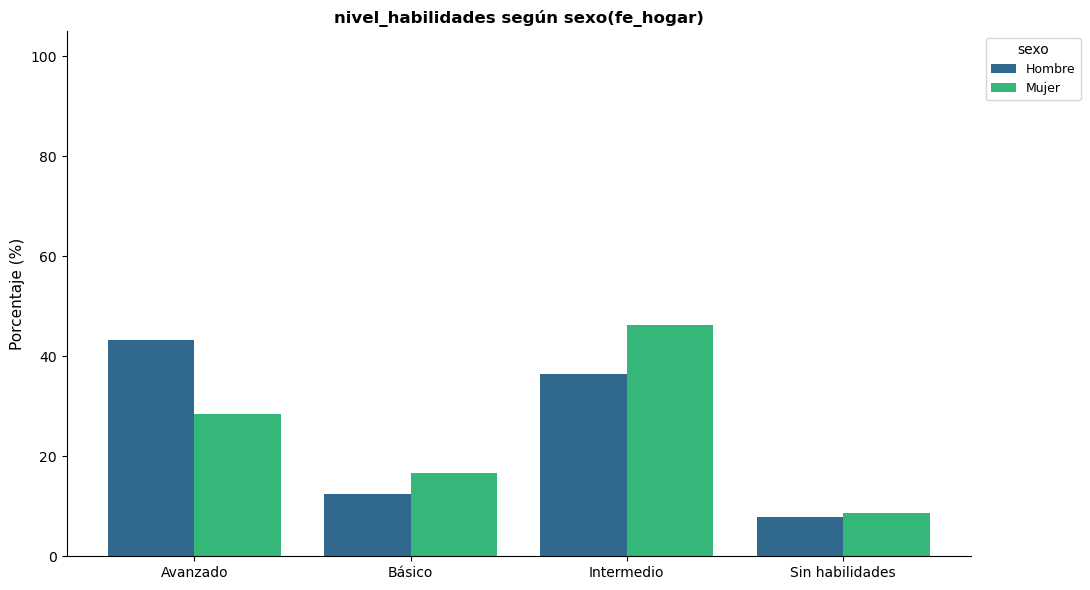

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'nivel_habilidades según sexo(fe_hogar)'}, ylabel='Porcentaje (%)'>)

In [21]:
generar_grafico('nivel_habilidades', cruce='sexo', factor='fe_hogar', palette='viridis')